In [210]:
words = open('dataset/processed/brand_name.txt', 'r').read().splitlines()
print(words[:10])

['admium', 'cadmes', 'acredion', 'easysize', 'frontrunnerit', 'quandoo', 'envested', 'tryout', 'msdc', 'inspiredme']


In [211]:
len(words)

50000

In [212]:
print(min(len(word) for word in words))
print(max(len(word) for word in words))

4
19


In [213]:
b = {}
for w in words:
    chs = ['<S>'] + list(w) + ['<E>']
    for ch1, ch2 in zip(chs, chs[1:]):
        bigram = (ch1, ch2)
        b[bigram] = b.get(bigram, 0) + 1

In [214]:
sorted(b.items(), key = lambda kv: -kv[1])

[(('e', '<E>'), 6892),
 (('s', '<E>'), 6832),
 (('e', 'r'), 6422),
 (('i', 'n'), 5709),
 (('<S>', 's'), 5072),
 (('t', 'e'), 4928),
 (('r', 'e'), 4810),
 (('e', 'n'), 4568),
 (('a', 'r'), 4485),
 (('t', '<E>'), 4414),
 (('o', 'n'), 4342),
 (('<S>', 'c'), 4203),
 (('<S>', 'a'), 3978),
 (('a', 'n'), 3970),
 (('s', 't'), 3862),
 (('c', 'o'), 3838),
 (('a', '<E>'), 3757),
 (('o', 'r'), 3548),
 (('r', 'a'), 3464),
 (('a', 'l'), 3452),
 (('<S>', 'm'), 3362),
 (('r', 'o'), 3331),
 (('l', 'e'), 3330),
 (('n', 'e'), 3319),
 (('t', 'i'), 3278),
 (('e', 's'), 3260),
 (('n', 't'), 3139),
 (('n', '<E>'), 3123),
 (('o', '<E>'), 3106),
 (('<S>', 'p'), 3102),
 (('i', 't'), 3022),
 (('m', 'a'), 3016),
 (('l', 'i'), 2978),
 (('a', 't'), 2937),
 (('r', 'i'), 2912),
 (('e', 'l'), 2877),
 (('m', 'e'), 2816),
 (('r', '<E>'), 2795),
 (('t', 'a'), 2795),
 (('<S>', 't'), 2756),
 (('<S>', 'b'), 2750),
 (('i', 'c'), 2734),
 (('e', 'c'), 2706),
 (('d', 'e'), 2698),
 (('t', 'r'), 2513),
 (('l', 'a'), 2513),
 (('<S

In [215]:
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
itos
# stoi

{1: 'a',
 2: 'b',
 3: 'c',
 4: 'd',
 5: 'e',
 6: 'f',
 7: 'g',
 8: 'h',
 9: 'i',
 10: 'j',
 11: 'k',
 12: 'l',
 13: 'm',
 14: 'n',
 15: 'o',
 16: 'p',
 17: 'q',
 18: 'r',
 19: 's',
 20: 't',
 21: 'u',
 22: 'v',
 23: 'w',
 24: 'x',
 25: 'y',
 26: 'z',
 0: '.'}

In [216]:
import torch 
N = torch.zeros((27,27 ), dtype=torch.int32)

In [217]:
for w in words:
    chs = ['.'] + list(w) + ['.']
    for ch1, ch2 in zip(chs, chs[1:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        N[ix1, ix2] += 1     
N

tensor([[   0, 3978, 2750, 4203, 2045, 2467, 1959, 1603, 1520, 2385,  605, 1138,
         1718, 3362, 1613, 1204, 3102,  344, 1725, 5072, 2756,  618, 1383, 1448,
          207,  331,  464],
        [3757,  369, 1093, 2196, 1646,  234,  622, 1018,  166, 1151,   65,  581,
         3452, 1601, 3970,   79, 1495,   77, 4485, 2136, 2937,  665,  773,  315,
          374,  757,  302],
        [ 611, 1056,  160,  148,   55, 1251,   33,   41,   28, 1178,   17,   19,
          817,   63,   28, 1161,   52,    5,  869,  249,   69,  541,   25,   32,
            7,  190,   19],
        [1406, 2389,   54,  339,   57, 1942,   55,   52, 2467, 1036,   10, 1009,
          775,  112,   95, 3838,   86,   23,  956,  577, 1252,  611,   37,   29,
           29,  249,    2],
        [1980, 1162,  159,  256,  222, 2698,  116,  238,  102, 2268,   27,   40,
          200,  217,   75,  860,  126,   13,  569,  646,  164,  349,  191,  156,
           77,  252,   53],
        [6892, 2426,  814, 2706, 2159, 1421,  458,

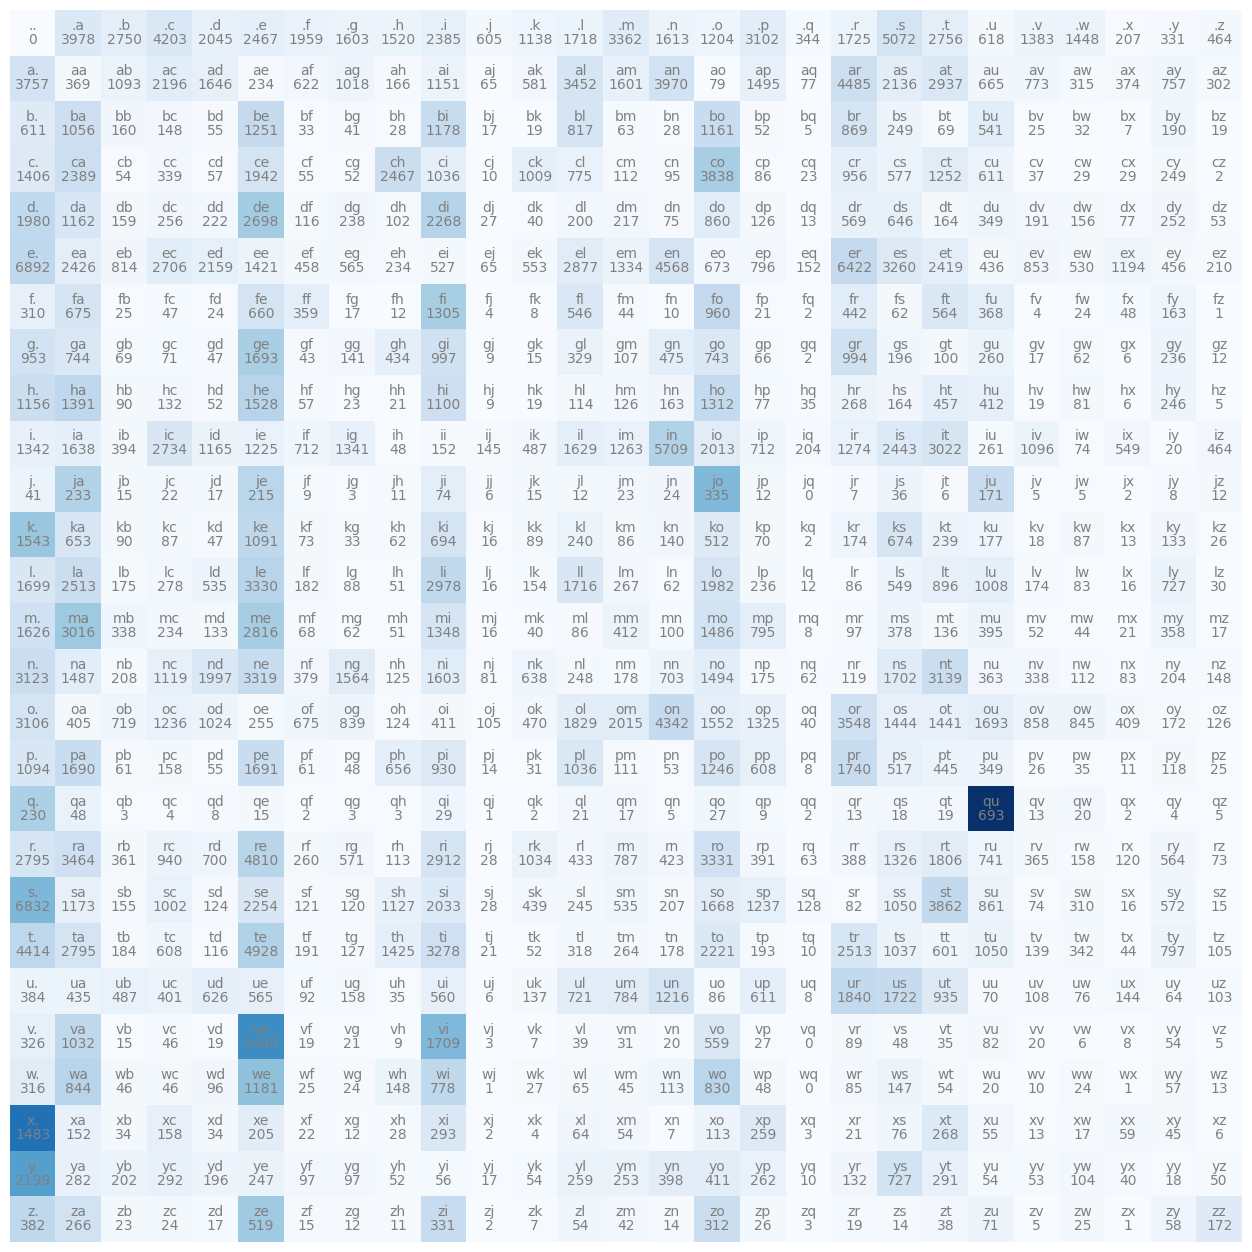

In [ ]:
import matplotlib.pyplot as plt 

plt.figure(figsize=(16,16))
plt.imshow(N, cmap='Blues')
for i in range(27):
    for j in range(27):
        chstr = itos[i] + itos[j]
        plt.text(j, i, chstr, ha="center", va="bottom", color="gray")
        plt.text(j, i, N[i,j].item(), ha="center", va="top", color="gray")
plt.axis('off')
plt.show()

In [219]:
p = N[0].float()
p = p / p.sum()
p

tensor([0.0000, 0.0796, 0.0550, 0.0841, 0.0409, 0.0493, 0.0392, 0.0321, 0.0304,
        0.0477, 0.0121, 0.0228, 0.0344, 0.0672, 0.0323, 0.0241, 0.0620, 0.0069,
        0.0345, 0.1014, 0.0551, 0.0124, 0.0277, 0.0290, 0.0041, 0.0066, 0.0093])

In [270]:
P = N.float()
P /= P.sum(dim=1, keepdim=True)

In [272]:
g = torch.Generator().manual_seed(42)

for i in range(6):
    out = []
    ix = 0
    while True:
        p = P[ix]
        ix = torch.multinomial(p, num_samples=1, replacement=True, generator=g).item()
        out.append(itos[ix])
        if ix == 0:
            break
    print("".join(out))   

ctugeenvt.
s.
fabidushontubun.
silayperaremareliole.
epicchoden.
dspe.


In [ ]:
total=[]
for w in words[:6]:
    chs = ['.'] + list(w) + ['.']
    for ch1, ch2 in zip(chs, chs[1:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        prod = P[ix1, ix2]
        total.append(prod)
        print(f"{ch1}{ch2}: {prod*100}")

.a: 7.955999851226807
ad: 4.532437324523926
dm: 1.6419490575790405
mi: 9.53796100616455
iu: 0.8126790523529053
um: 6.335865497589111
m.: 11.504988670349121
.c: 8.406000137329102
ca: 12.259454727172852
ad: 4.532437324523926
dm: 1.6419490575790405
me: 19.924999237060547
es: 7.244444847106934
s.: 26.006851196289062
.a: 7.955999851226807
ac: 6.046921253204346
cr: 4.905834674835205
re: 16.610836029052734
ed: 4.797778129577637
di: 17.16101837158203
io: 6.267903804779053
on: 14.002837181091309
n.: 12.638096809387207
.e: 4.934000015258789
ea: 5.391111373901367
as: 5.881705284118652
sy: 2.1773886680603027
ys: 10.608492851257324
si: 7.738865852355957
iz: 1.4447627067565918
ze: 21.071863174438477
e.: 15.31555461883545
.f: 3.9179999828338623
fr: 6.592095851898193
ro: 11.503263473510742
on: 14.002837181091309
nt: 12.702844619750977
tr: 8.990734100341797
ru: 2.558966636657715
un: 9.827056884765625
nn: 2.8448867797851562
ne: 13.431265830993652
er: 14.271111488342285
ri: 10.056289672851562
it: 9.40964

In [307]:
1/27

0.037037037037037035